# Aula 3 - Introdução à análise de dados

**Conteúdos:**
- Dados em planilhas
- Organização de dados
- Pandas
- Gráficos
- Análise gráfica de dados
- Matplotlib + seaborn

## Dados em planilhas

Comumente guardamos dados em planilhas! como no excel.

Normalmente para programar, utilizamos os dados em um formato chamado `.csv` (valores separados por vírgula, _comma separated values_)

Esse tipo de arquivo se para com isso:

```csv
nome,idade,altura,sexo
Frederico,20,185,"M"
Nick,22,178,"M"
Joana,,165,"F"
```
Descrevendo a seguinte tabela
| nome | idade | altura | sexo |
|------|-------|--------|------|
| Frederico | 20 | 185 | M |
| Nick | 22 | 178 | M |
| Joana | | 165 | "F" |

## Dados da aula

Dataset `penguins` disponível na biblioteca `seaborn`:

Instalamos a biblioteca com:

`!pip install seaborn`

Importamos os dados assim:
```python
import seaborn as sns

dados_pinguins = sns.load_dataset("penguins")
```
Perceba que demos um "apelido" (`sns`) para a bibliteca, isso deixa mais fácil de digitar

com `sns.load_dataset("penguins")` carregamos os daddos na variavel `dados_pinguins`

---

> Dados do seguinte estudo: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0090081

| species | island | bill_length_mm | bill_depth_mm | flipper_length_mm | body_mass_g | sex |
|---------|--------|----------------|---------------|-------------------|-------------|-----|
| Adelie | Torgersen | 39.1 | 18.7 | 181 | 3750 | MALE |
| Chinstrap | Dream | 47.5 | 16.8 | 199 | 3900 | FEMALE |
| Gentoo | Biscoe | 51.1 | 16.5 | 225 | 5250 | MALE | 

Cada linha da tabela representa um pinguim que teve os dados coletados

Cada coluna representa uma característica do pinguim, respectivamente:

espécie, ilha, comprimento do bico, altura do bico, comprimento da asa, peso e sexo

- os comprimentos e alturas estão em milímetros

- o peso está em gramas


In [50]:
# Instale a biblioteca
#!pip install seaborn

In [51]:
# Importe a biblioteca e salve os dados em uma variável
import seaborn as sns
dados_pinguins = sns.load_dataset("penguins")

In [52]:
# De um print nos dados
print(dados_pinguins)

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female  
2     

## Como analisar esses dados com python?

Utilizaremos a biblioteca `pandas`!

Para instalar:
`!pip install pandas`

Normalmente importamos essa biblioteca com o apelido de `pd` assim:

``` python
import pandas as pd
```

Que tipo é a tabela no python?

_Hmm vamos rodar `type(dados_pinguins)` para descobrir_

In [53]:
# Veja o tipo dos dados carregados?
type(dados_pinguins)

pandas.core.frame.DataFrame

## Como podemos visualizar os dados?

O jupyter notebook, tem uma maneira especial de mostrar tabelas do `pandas`, para utilizá-la basta digitar o nome da tabela como a última linha do bloco de código.

In [54]:
# Veja a tabela importada
dados_pinguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Temos diversos métodos para observar melhor os dados como:
- `tabela.info()` -> Mostra todas as colunas e os tipos de seus dados
- `tabela.columns` -> Lista as colunas da tabela (_perceba que não é uma função_)
- `tabela.describe()` -> Faz medidas padrão das colunas numéricas
- `tabela.head(n)` -> mostra as `n` primeiras linhas da tabela

In [55]:
# Teste algumas das funções mostradas acima
dados_pinguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Da pra isolar um dado único

Sim! podemos resgatar da tabela somente uma linha ou somente uma coluna

**Resgatando uma coluna**

É igual a resgatar um valor no dicionário:
```python
tabela["nome_da_coluna"]
```

In [56]:
# Tente isolar a variável coluna 
dados_pinguins["sex"]

0        Male
1      Female
2      Female
3         NaN
4      Female
        ...  
339       NaN
340    Female
341      Male
342    Female
343      Male
Name: sex, Length: 344, dtype: object

**Resgatando uma linha**
```python
tabela.loc[n]
```

Esse comando retorna a n-ésima linha da tabela.

> Perceba que não é `loc()` como se fosse uma função, é `loc[]` com colchetes!

In [ ]:
# Mostre uma linha da tabela
dados_pinguins.loc[3]

species                 Adelie
island               Torgersen
bill_length_mm             NaN
bill_depth_mm              NaN
flipper_length_mm          NaN
body_mass_g                NaN
sex                        NaN
Name: 3, dtype: object

**Resgatando um valor de uma coluna**

```python
tabela.loc[3, "nome_da_coluna"]
```
Assim pegamos sóo o valor da linha `3` na coluna `"nome_da_coluna"`

In [58]:
# Resgate um valor específico na tabela
dados_pinguins.loc[5, "island"]

'Torgersen'

## Alguns métodos das colunas

> Lmebrando, para resgatar uma coluna fazemos
>    ```python
>    taela["nome_da_coluna"]
>    ```

Podemos medir várias coisas nas colunas com os seguintes métodos
- `tabela["nome_coluna"].count()` -> conta quantos elementos tem naquela coluna
- `tabela["nome_coluna"].value_counts()` -> retorna uma tabela contando quantos elementos tem com cada valor

In [59]:
# Teste o value_counts() na coluna "Species" para descobrir quantos pinguins de cada espécie temos
dados_pinguins["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## Como filtrar meus dados?

Podemos filtrar os dados utilizando a **indexação booleana**

__o nome parece mais assustador do que é de fato__

Fazmos assim:
```python
tabela_filtrada = tabela[tabela["nome_coluna"] == "valor"]
```

> Leia isso como:\
> tabela filtrada é a tabela onde a coluna "nome_coluna" é igual a "valor"

In [60]:
# Filtre somente uma das espécias de pinguim ex.: "Gentoo"
tabela_filtrada = dados_pinguins[dados_pinguins["species"] == "Gentoo"]
tabela_filtrada

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,Female
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Filtragem avançada

Podemos juntas varios filtros com os símbolos `&` (semelhante ao `and`), `|` (semelhante ao `or`) e `~` (semelhante ao `not`)

Exemplo:
```python
tabela_filtrada = tabela[(tabela["species"] == "Gentoo") & (tabela["body_mass_g"] > 100)]
```
Isso seleciona somente os pinguins da espécie Gentoo com mais de 100 gramas

In [61]:
# Construa outro exemplo de filtragem avançada
gentoo_pesados = dados_pinguins[(dados_pinguins["species"] == "Gentoo") & (dados_pinguins["body_mass_g"] > 3900)]
gentoo_pesados

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,Female
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


- Outro exemplo de filtragem é quando queremos remover linhas que tem valores faltando, para isso temos a função `.dropna()`
```python
tabela.dropna(inplace=True)
```

In [62]:
# remova as linhas com valores faltando do dataset
dados_pinguins.dropna(inplace=True)
dados_pinguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Como modificar meus dados?

Quero editar minhas tabelas com o python, como faço?

Vamos ver diferentes alterações:
- Modificar o nome de uma coluna
    ```python
    tabela.rename(columns={"nome_antigo" : "nome_novo"}, inplace=True)
    ```

In [63]:
# troque o nome da coluna Island por Habitat
dados_pinguins.rename(columns={"island" : "habitat"}, inplace=True)
dados_pinguins.columns

Index(['species', 'habitat', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

- Atualização de um valor específico com `.loc`
    ```python
    tabela.loc[n, "atributo"] = novo_valor
    ```

In [64]:
# Troque o habitat do 55 pinguim para "Maldivas"
dados_pinguins.loc[55, "habitat"] = "Maldivas"
dados_pinguins.loc[55]

species                Adelie
habitat              Maldivas
bill_length_mm           41.4
bill_depth_mm            18.6
flipper_length_mm       191.0
body_mass_g            3700.0
sex                      Male
Name: 55, dtype: object

- Atualização de uma coluna inteira
    - Exemplo adicionar 1 a idade em uma tabela de idades:
        ```python
        tabela["idade"] = tabela["idade"] + 1
        ```
    - Com esse método também podemos criar novas colunas
        - Exemplo onde a coluna nova é a antiga vezes 10
            ```python
            tabela["coluna_nova"] = tabela["coluna_antiga"] * 10
            ```

In [65]:
# Adicione uma coluna nova no dataset dos pinguins que é "peso_em_kg" fazendo a coluna "body_mass_g" / 1000
dados_pinguins["peso_em_kg"] = dados_pinguins["body_mass_g"] / 1000
dados_pinguins

,species,habitat,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,peso_em_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3.750
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3.800
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3.250
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3.450
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3.650
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,4.925
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,4.850
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,5.750
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,5.200


- Remoção de uma coluna
    ```python
    tabela.drop(columns=["coluna_1", "coluna_2"], inplace=True)
    ```

In [66]:
# Remova a coluna "Habitat" da tabela
dados_pinguins.drop(columns=["habitat"], inplace=True)
dados_pinguins.columns

Index(['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex', 'peso_em_kg'],
      dtype='object')

## Gráficos!!

Para fazer gráficos usaremos as bibliotecas `seaborn` (já instalamos!) e `matplotlib`

> Para instalar o `matplotlib` rodamos:

`!pip install matplotlib`

In [ ]:
# Instale o matplotlib
#!pip install matplotlib

Para importar as bibliotecas utilizamos alguns apelidos, que quase todos os programadores usam de forma padronizada
```python
import seaborn as sns
import matplotlib.pyplot as plt
```

- Esses apelidos são completamente arbitrários, podemos subsititui-los por qualquer coisa, mas geralmente tem um específico que é mais utilizado para cada biblioteca

In [73]:
# importe as duas bibliotecas
import seaborn as sns
import matplotlib.pyplot as plt

## Como eu gero um gráfico?

Para gerar um gráfico temos um comando com esse formato:
```python
sns.___plot(tabela, x="coluna_x", y="coluna_y", hue="coluna_cor")
plt.show()
```

---

- Vamos começar com um gráfico de pontos!

Utilize a função ```sns.scatterplot()```

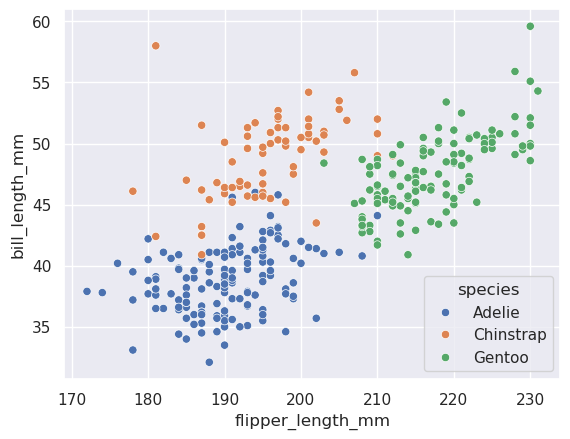

In [80]:
# Crie o gráfico de pontos do exemplo
sns.set_theme()
sns.scatterplot(dados_pinguins, x = "flipper_length_mm", y="bill_length_mm", hue="species")
plt.show()

- Vamos tentar fazer uma distribuição!

Utilize a função `sns.displot()`

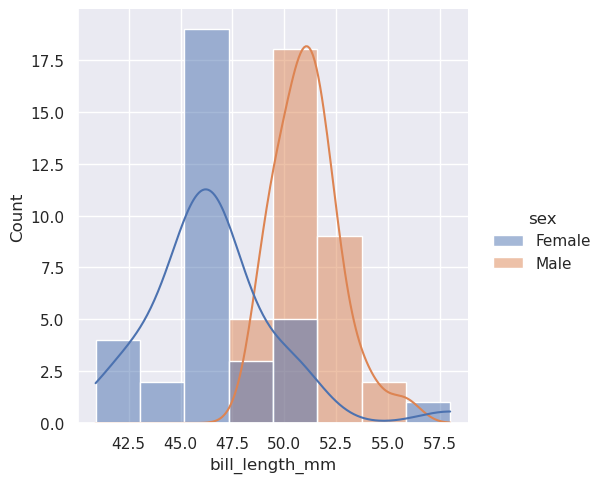

In [82]:
# Crie o gráfico de distribuição do exemplo
data_chin = dados_pinguins[dados_pinguins["species"] == "Chinstrap"]

sns.displot(data_chin, x="bill_length_mm", hue="sex", kde=True)
plt.show()

- Vamos comparar distribuições com um gráfico de violino

Utilize a função `sns.violinplot`

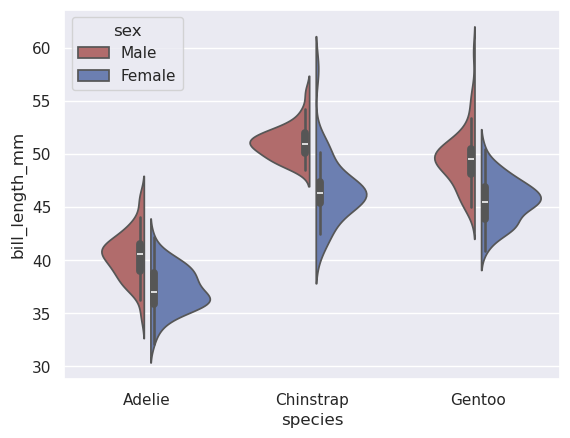

In [84]:
# Crie um gráfico de violino do exemplo
sns.violinplot(dados_pinguins, x="species", y="bill_length_mm", hue="sex", split=True, gap=0.1, palette=["#bd6060", "#607abd"])
plt.show()

## Tu pode explorar os dados!

Utilize esse espaço para fazer outros plots disponíveis no `seaborn` ou para testar outras colunas dos nossos dados!

Eles tem um site bem legal com vários exemplos:

https://seaborn.pydata.org/examples/index.html

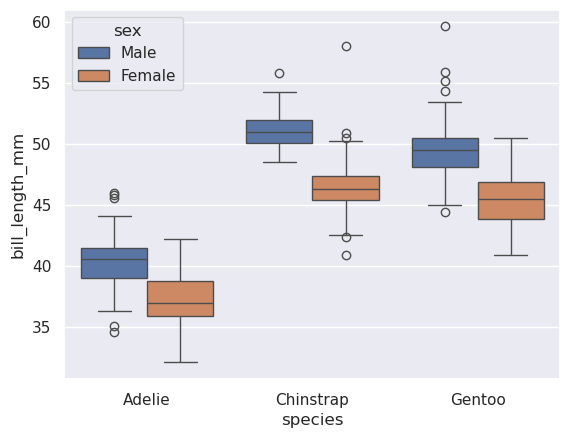

In [86]:
# Fique a vontade para explorar os dados
sns.boxplot(dados_pinguins, x="species", y="bill_length_mm", hue="sex")
plt.show()